# Assignment 2: APIs, Data Formats, Databases, and EDA

## Statement of use of AI

I completed most tasks in this assignment without AI. I used AI to help understand the
structure of the MarketStack JSON response and to help write the SQL JOIN
query in Task 5c because I do not have sufficient previous knowledge of databases.
I wrote, read and understood every line of code in this notebook before submitting it.

In [1]:
# Imports used throughout the notebook
import os
import json
import time
import sqlite3

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

# Make plots show inline and look consistent
sns.set_theme(style="whitegrid")

### Task 0: Course project dataset exploration

**0a) Dataset source.** I am considering the *Diamonds* dataset, which ships
with seaborn and is originally published in the `ggplot2` R package by
Hadley Wickham. Source: https://ggplot2.tidyverse.org/reference/diamonds.html

**0b) Description.** The dataset contains 53,940 rows and 10 columns describing
individual diamonds sold in a US retailer. The variables are:

- `price` (US dollars) — the sale price
- `carat` — weight of the diamond
- `cut`, `color`, `clarity` — quality categories
- `depth`, `table` — physical proportions (%)
- `x`, `y`, `z` — length, width, depth in mm

For the course project I plan to investigate which attributes drive the price
of a diamond and whether there are categories that are systematically under-
or overpriced compared to their carat. This is a classic retail-pricing
business-intelligence question.

In [2]:
# --- Task 0c: Exploratory data analysis of the project dataset ---

# Load the built-in dataset (no download needed)
diamonds = sns.load_dataset("diamonds")

# Quick look at what we have
print("Shape:", diamonds.shape)
print()
print("Data types:")
print(diamonds.dtypes)
print()
print("First 5 rows:")
diamonds.head()

Shape: (53940, 10)

Data types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# Summary statistics for the numeric columns
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


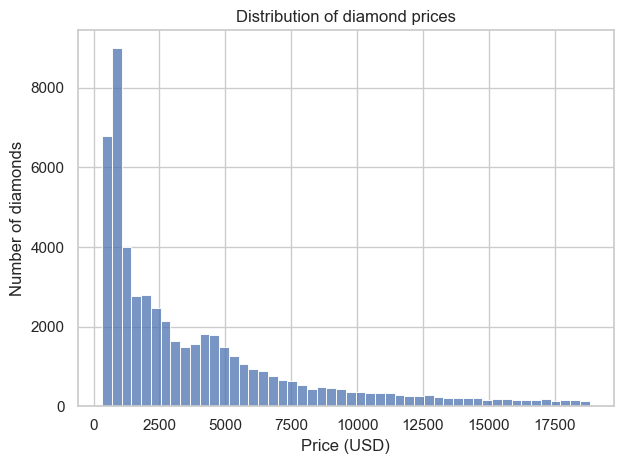

In [4]:
# Visualization 1: distribution of diamond prices
sns.histplot(data=diamonds, x="price", bins=50)
plt.title("Distribution of diamond prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of diamonds")
plt.tight_layout()
plt.show()

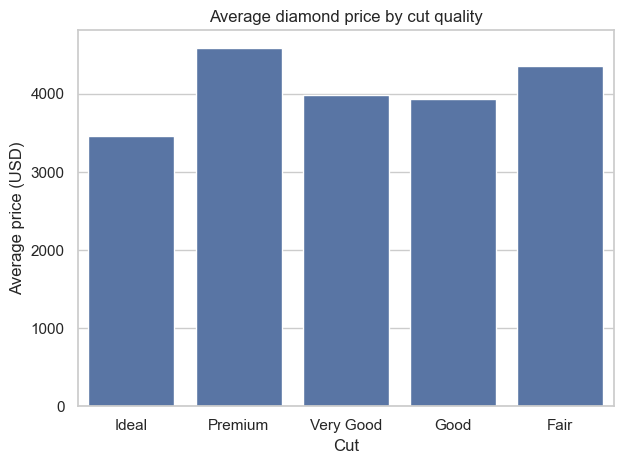

In [5]:
# Visualization 2: average price per cut quality
avg_price_per_cut = diamonds.groupby("cut", observed=False)["price"].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_per_cut.index, y=avg_price_per_cut.values)
plt.title("Average diamond price by cut quality")
plt.xlabel("Cut")
plt.ylabel("Average price (USD)")
plt.tight_layout()
plt.show()

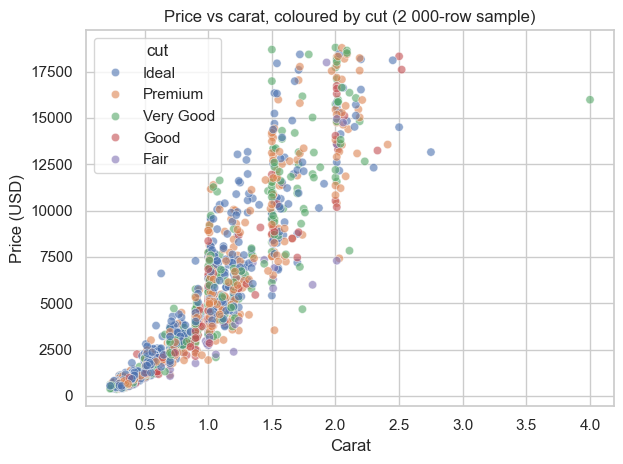

In [6]:
# Visualization 3 (a bit extra, to show relationships):
# price vs carat, colored by cut
sns.scatterplot(data=diamonds.sample(2000, random_state=42),
                x="carat", y="price", hue="cut", alpha=0.6)
plt.title("Price vs carat, coloured by cut (2 000-row sample)")
plt.xlabel("Carat")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

### Task 1: Setting up an API key and .env file

In [7]:
# Task 1: load the MarketStack API key from .env ---

load_dotenv()  # reads the .env file and puts the variables into os.environ

api_key = os.environ.get("MARKETSTACK_API_KEY")

# Show only the first 5 characters to prove it loaded, never the full key
if api_key:
    print("Key loaded:", api_key[:5] + "...")
else:
    print("ERROR: MARKETSTACK_API_KEY not found. Check your .env file.")

Key loaded: 21ad4...


### Task 2: Retrieving data from MarketStack

In [8]:
# --- Task 2a: retrieve End-of-Day data for the FAANG stocks in March 2026 ---

url = "https://api.marketstack.com/v2/eod"
params = {
    "access_key": api_key,
    "symbols":    "META,AAPL,AMZN,NFLX,GOOG",
    "date_from":  "2026-03-01",
    "date_to":    "2026-03-31",
    "limit":      1000
}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

faang_json = response.json()
print("Number of records returned:", len(faang_json["data"]))

Status code: 200
Number of records returned: 110


In [9]:
# --- Task 2b: convert the JSON response to a DataFrame ---

faang_df = pd.DataFrame(faang_json["data"])

# Keep only the columns we need
faang_df = faang_df[["symbol", "date", "open", "high", "low", "close", "volume"]]

# Convert date to datetime and sort chronologically
faang_df["date"] = pd.to_datetime(faang_df["date"])
faang_df = faang_df.sort_values(["symbol", "date"]).reset_index(drop=True)

print("Shape:", faang_df.shape)
faang_df.head()

Shape: (110, 7)


,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,266.530,260.20,264.72,41576035.0
1,AAPL,2026-03-03 00:00:00+00:00,263.480,265.560,260.13,263.75,37994695.0
2,AAPL,2026-03-04 00:00:00+00:00,264.650,266.150,261.42,262.52,39258957.0
3,AAPL,2026-03-05 00:00:00+00:00,260.745,261.555,257.25,260.29,49424671.0
4,AAPL,2026-03-06 00:00:00+00:00,258.740,258.760,254.37,257.46,40628988.0


In [10]:
# --- Task 2c: summary statistics for closing prices per stock ---

close_stats = faang_df.groupby("symbol")["close"].describe()
print("Summary of closing prices per stock:")
display(close_stats)

Summary of closing prices per stock:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [11]:
# --- Task 2c continued: return % over March 2026 ---

# For each stock, first trading day's close vs last trading day's close
returns = {}
for symbol in faang_df["symbol"].unique():
    one_stock = faang_df[faang_df["symbol"] == symbol]
    first_close = one_stock["close"].iloc[0]
    last_close  = one_stock["close"].iloc[-1]
    pct_change  = (last_close - first_close) / first_close * 100
    returns[symbol] = round(pct_change, 2)

returns_df = pd.DataFrame(
    list(returns.items()),
    columns=["symbol", "return_pct"]
).sort_values("return_pct", ascending=False).reset_index(drop=True)

print("March 2026 return per stock:")
display(returns_df)

best  = returns_df.iloc[0]
worst = returns_df.iloc[-1]
print(f"Best  performer: {best['symbol']} ({best['return_pct']:.2f}%)")
print(f"Worst performer: {worst['symbol']} ({worst['return_pct']:.2f}%)")

March 2026 return per stock:


,symbol,return_pct
0,AMZN,-0.06
1,NFLX,-0.97
2,AAPL,-4.13
3,GOOG,-6.37
4,META,-12.46


Best  performer: AMZN (-0.06%)
Worst performer: META (-12.46%)


### Task 3: Visualizing stock data

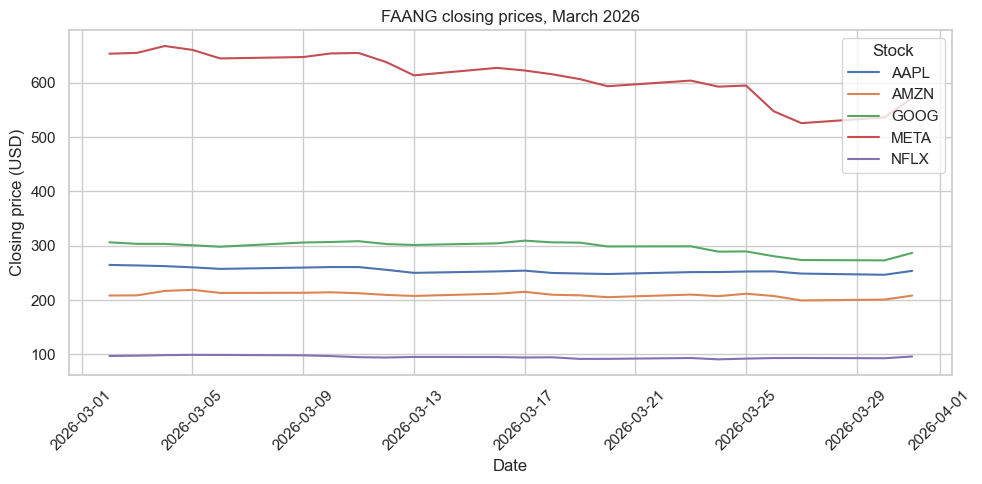

In [12]:
# --- Task 3a: line chart of closing price over time ---

plt.figure(figsize=(10, 5))
sns.lineplot(data=faang_df, x="date", y="close", hue="symbol")
plt.title("FAANG closing prices, March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")
plt.xticks(rotation=45)
plt.legend(title="Stock")
plt.tight_layout()
plt.show()

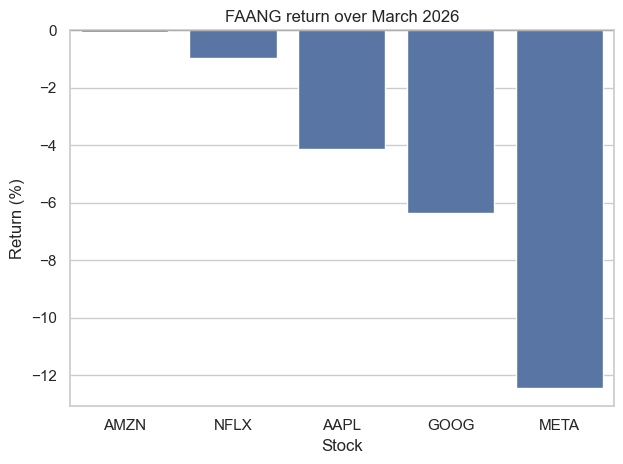

In [13]:
# --- Task 3b: bar plot of overall return % per stock ---

sns.barplot(data=returns_df, x="symbol", y="return_pct")
plt.title("FAANG return over March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

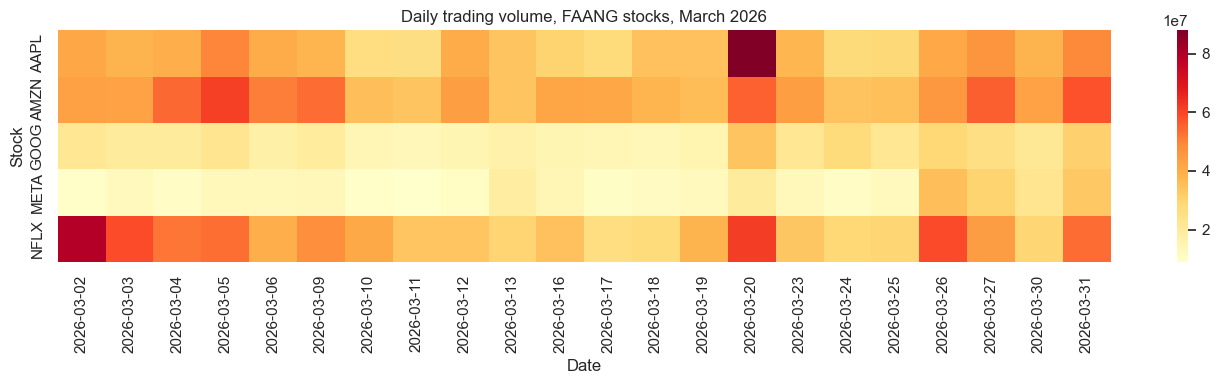

In [14]:
# --- Task 3c: heatmap of daily trading volume, stocks on y, dates on x ---

# pivot() rearranges the long DataFrame into a matrix
volume_matrix = faang_df.pivot(index="symbol", columns="date", values="volume")

# Format the date columns as short strings so the x-axis labels fit
volume_matrix.columns = volume_matrix.columns.strftime("%Y-%m-%d")

plt.figure(figsize=(14, 4))
sns.heatmap(volume_matrix, cmap="YlOrRd")
plt.title("Daily trading volume, FAANG stocks, March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

### Task 4: Exporting and importing data

In [15]:
# --- Task 4a: export the raw JSON from Task 2a ---

with open("exports/stockdata.json", "w") as f:
    json.dump(faang_json, f, indent=2)

print("JSON file saved to exports/stockdata.json")

JSON file saved to exports/stockdata.json


In [16]:
# --- Task 4b: export the DataFrame from Task 2b as CSV ---

faang_df.to_csv("exports/stockdata.csv", index=False)
print("CSV file saved to exports/stockdata.csv")

CSV file saved to exports/stockdata.csv


In [17]:
# --- Task 4c: load both files back and verify ---

# Reload the JSON
with open("exports/stockdata.json", "r") as f:
    json_back = json.load(f)

print("Reloaded JSON — first data record:")
print(json_back["data"][0])
print()

# Reload the CSV
csv_back = pd.read_csv("exports/stockdata.csv")
csv_back["date"] = pd.to_datetime(csv_back["date"])

print("Reloaded CSV — first 5 rows:")
display(csv_back.head())

Reloaded JSON — first data record:
{'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'name': 'Apple Inc', 'exchange_code': 'NASDAQ', 'asset_type': 'Stock', 'price_currency': 'USD', 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}

Reloaded CSV — first 5 rows:


,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02 00:00:00+00:00,262.440,266.530,260.20,264.72,41576035.0
1,AAPL,2026-03-03 00:00:00+00:00,263.480,265.560,260.13,263.75,37994695.0
2,AAPL,2026-03-04 00:00:00+00:00,264.650,266.150,261.42,262.52,39258957.0
3,AAPL,2026-03-05 00:00:00+00:00,260.745,261.555,257.25,260.29,49424671.0
4,AAPL,2026-03-06 00:00:00+00:00,258.740,258.760,254.37,257.46,40628988.0


### Task 5: Querying the Northwind database

In [18]:
# --- Task 5a: connect to the SQLite database and list all tables ---

connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

print("Tables in the Northwind database:")
for table in tables:
    print("-", table[0])

Tables in the Northwind database:
- Categories
- sqlite_sequence
- CustomerCustomerDemo
- CustomerDemographics
- Customers
- Employees
- EmployeeTerritories
- Order Details
- Orders
- Products
- Regions
- Shippers
- Suppliers
- Territories


In [19]:
# --- Task 5b: products with unit price above 30 ---

query = """
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
"""

products_expensive = pd.read_sql_query(query, connection)
print("Shape:", products_expensive.shape)
products_expensive

Shape: (24, 3)


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [20]:
# --- Task 5c: orders shipped to Germany (JOIN across three tables) ---

query_germany = """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN "Order Details" od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
"""

germany_orders = pd.read_sql_query(query_germany, connection)
print("Shape:", germany_orders.shape)
germany_orders.head()

Shape: (80673, 5)


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


### Task 6: Visualizing Northwind data

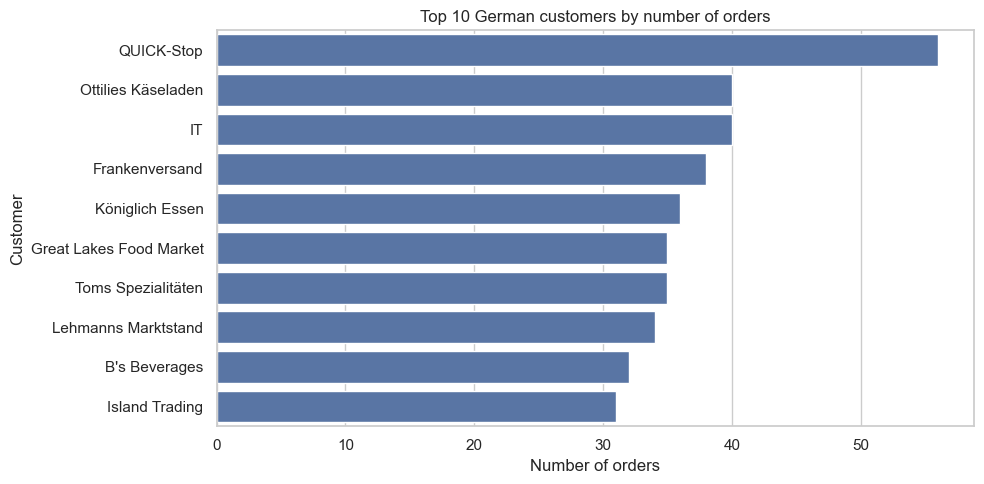

In [21]:
# --- Task 6a: top-10 Germany customers by number of orders ---

# Each row in germany_orders is an order-line, so count DISTINCT order IDs per customer
orders_per_customer = (
    germany_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"OrderID": "NumOrders"})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=orders_per_customer, x="NumOrders", y="CompanyName")
plt.title("Top 10 German customers by number of orders")
plt.xlabel("Number of orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

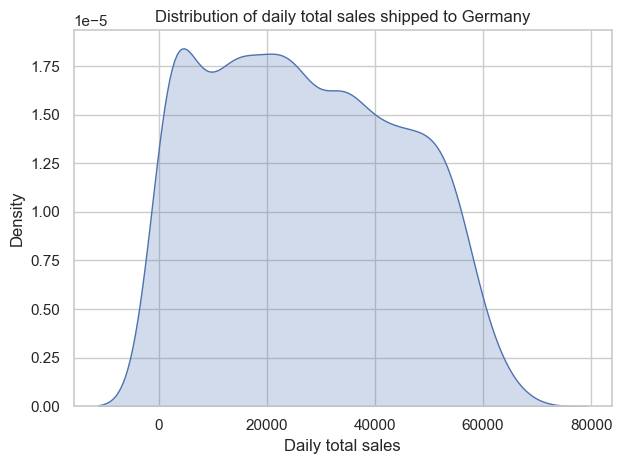

In [22]:
# --- Task 6b: distribution of daily total sales to Germany (KDE plot) ---

daily_germany = (
    germany_orders.groupby("OrderDate")["LineTotal"].sum().reset_index()
)

sns.kdeplot(data=daily_germany, x="LineTotal", fill=True)
plt.title("Distribution of daily total sales shipped to Germany")
plt.xlabel("Daily total sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

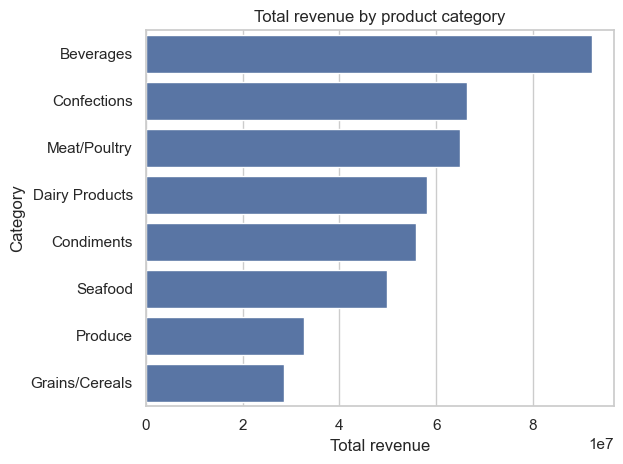

In [23]:
# --- Task 6c: total revenue per product category ---

query_cat = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM "Order Details" od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
"""

revenue_by_cat = pd.read_sql_query(query_cat, connection)
revenue_by_cat = revenue_by_cat.sort_values("TotalRevenue", ascending=False)

sns.barplot(data=revenue_by_cat, x="TotalRevenue", y="CategoryName")
plt.title("Total revenue by product category")
plt.xlabel("Total revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL

In [24]:
# --- Task 7a: load both full tables with read_sql_query ---

products_df = pd.read_sql_query("SELECT * FROM Products", connection)
categories_df = pd.read_sql_query("SELECT * FROM Categories", connection)

print("Products — first 5 rows:")
display(products_df.head())
print("Categories — first 5 rows:")
display(categories_df.head())

Products — first 5 rows:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories — first 5 rows:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [25]:
# --- Task 7b: inner join Products and Categories on CategoryID ---

joined_in_python = pd.merge(
    products_df, categories_df,
    how="inner",
    on="CategoryID"
)

print("Shape after join:", joined_in_python.shape)
joined_in_python.head()

Shape after join: (77, 13)


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [26]:
# --- Task 7c: reproduce Task 6c in pandas and time both approaches ---

# Approach 1: let SQL do the join (same query as Task 6c)
start_sql = time.time()
revenue_sql = pd.read_sql_query(query_cat, connection)
time_sql = time.time() - start_sql

# Approach 2: pull the raw tables via SQL, join and aggregate in pandas
start_py = time.time()

order_details = pd.read_sql_query('SELECT * FROM "Order Details"', connection)
products_raw = pd.read_sql_query("SELECT * FROM Products", connection)
categories_raw = pd.read_sql_query("SELECT * FROM Categories", connection)

merged = pd.merge(order_details, products_raw, how="inner", on="ProductID")
merged = pd.merge(merged, categories_raw, how="inner", on="CategoryID")
merged["LineTotal"] = merged["UnitPrice_x"] * merged["Quantity"]
revenue_py = merged.groupby("CategoryName")["LineTotal"].sum().reset_index()

time_py = time.time() - start_py

print(f"SQL join approach:    {time_sql:.4f} seconds")
print(f"Pandas join approach: {time_py:.4f} seconds")

if time_sql < time_py:
    print("SQL was faster — the database engine does the join and aggregation "
          "in one pass and only returns the small result.")
else:
    print("Pandas was faster in this run, but for larger databases SQL typically "
          "wins because the database avoids transferring every row into Python.")

# Close the database connection now that we are done
connection.close()

SQL join approach:    0.7236 seconds
Pandas join approach: 1.8504 seconds
SQL was faster — the database engine does the join and aggregation in one pass and only returns the small result.


### Task 8: Wide and long format

In [27]:
# --- Task 8a: wide_data -> long format with melt() ---

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

print("wide_data BEFORE (wide format):")
display(wide_data)

long_from_wide = wide_data.melt(
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("wide_data AFTER melt (long format):")
display(long_from_wide)

wide_data BEFORE (wide format):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


wide_data AFTER melt (long format):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [28]:
# --- Task 8b: long_data -> wide format with pivot() ---

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("long_data BEFORE (long format):")
display(long_data)

wide_from_long = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).reset_index()

month_order = ["Jan", "Feb", "Mar"]
wide_from_long["month"] = pd.Categorical(
    wide_from_long["month"], categories=month_order, ordered=True
)
wide_from_long = wide_from_long.sort_values("month").reset_index(drop=True)

print("long_data AFTER pivot (wide format):")
display(wide_from_long)

long_data BEFORE (long format):


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


long_data AFTER pivot (wide format):


product,month,Laptop,Phone
0,Jan,45,120
1,Feb,50,110
2,Mar,55,130


In [29]:
# --- Task 8c: reverse the transformations and compare to originals ---

# long-from-wide -> back to wide using pivot
back_to_wide = long_from_wide.pivot(
    index="store", columns="quarter", values="sales"
).reset_index()
back_to_wide.columns.name = None

print("Original wide_data:")
display(wide_data)
print("Reconstructed from long (should match):")
display(back_to_wide)

# wide-from-long -> back to long using melt
back_to_long = wide_from_long.melt(
    id_vars="month", var_name="product", value_name="units_sold"
)
# Same alphabetical ordering as the original long_data
back_to_long = back_to_long.sort_values(
    ["month", "product"]
).reset_index(drop=True)

print("Original long_data:")
display(long_data)
print("Reconstructed from wide (should match):")
display(back_to_long)

Original wide_data:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Reconstructed from long (should match):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Original long_data:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


Reconstructed from wide (should match):


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130
